In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
hassan06_nslkdd_path = kagglehub.dataset_download('hassan06/nslkdd')

print('Data source import complete.')


Using Colab cache for faster access to the 'nslkdd' dataset.
Data source import complete.



--- Binary Classification Metrics ---


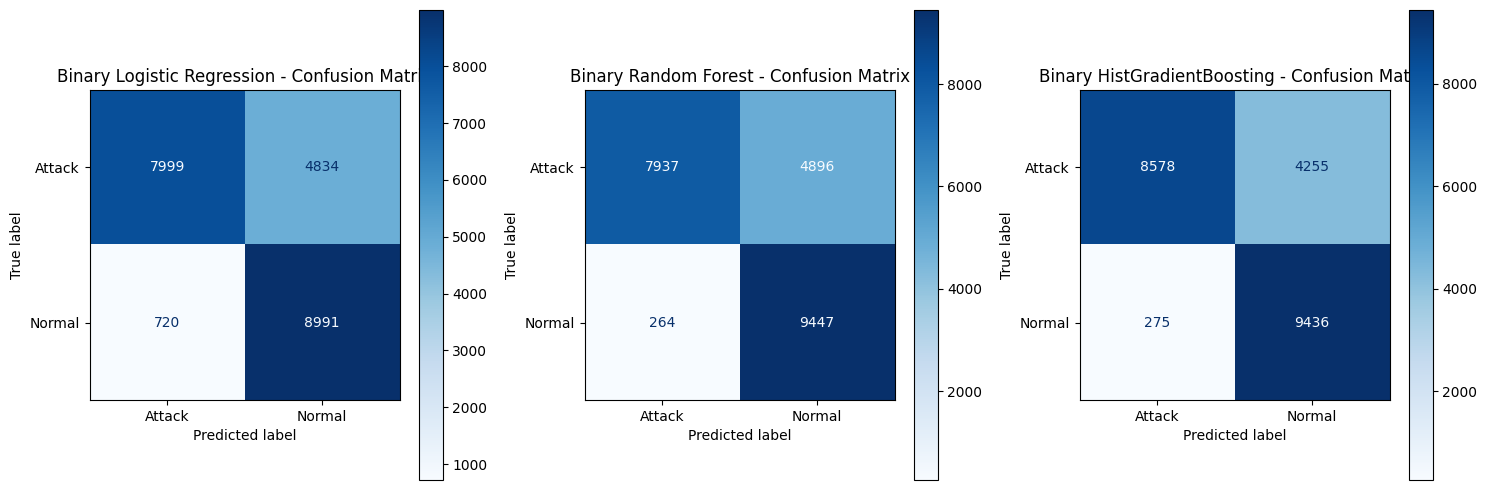

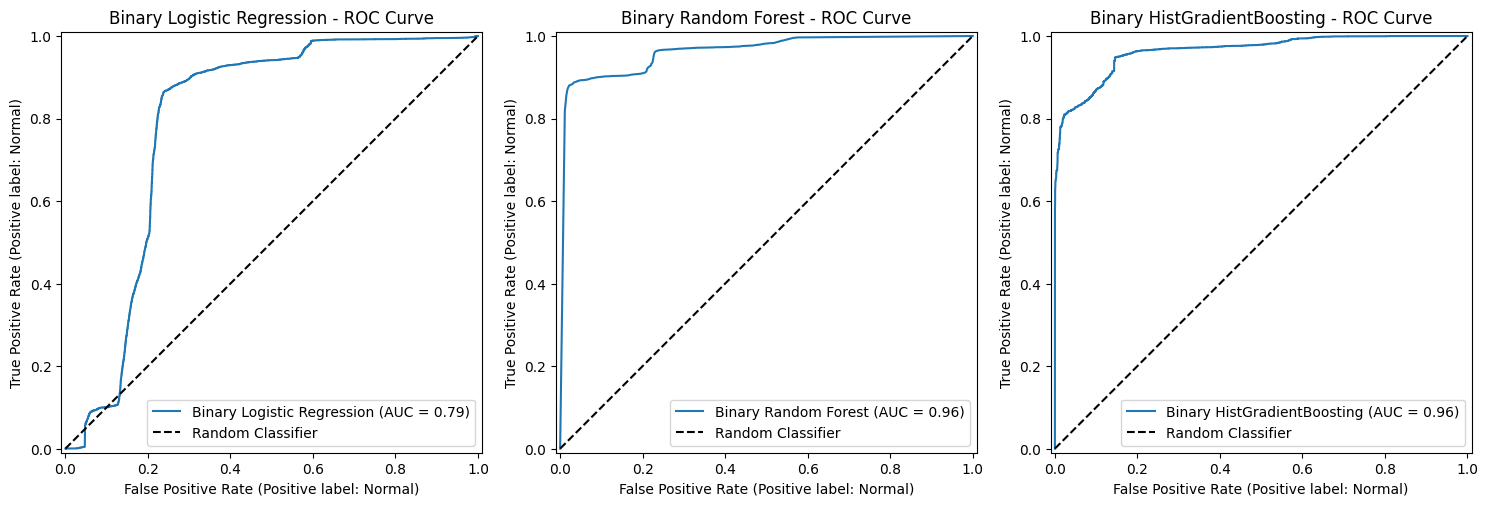

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# ===================================
# CONFUSION MATRICES & ROC CURVES
# ===================================

# BINARY CLASSIFICATION METRICS
print("\n--- Binary Classification Metrics ---")
binary_models = [
    (logreg_bin, "Binary Logistic Regression"),
    (rf_bin, "Binary Random Forest"),
    (hgb_bin, "Binary HistGradientBoosting")
]

plt.figure(figsize=(15, 5))
for i, (model, name) in enumerate(binary_models):
    # Confusion Matrix
    plt.subplot(1, len(binary_models), i + 1)
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test_bin, cmap='Blues', ax=plt.gca())
    plt.title(f'{name} - Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
for i, (model, name) in enumerate(binary_models):
    # ROC Curve
    plt.subplot(1, len(binary_models), i + 1)
    RocCurveDisplay.from_estimator(model, X_test, y_test_bin, name=name, ax=plt.gca())
    plt.title(f'{name} - ROC Curve')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.legend()
plt.tight_layout()
plt.show()


--- Multiclass Classification Metrics ---


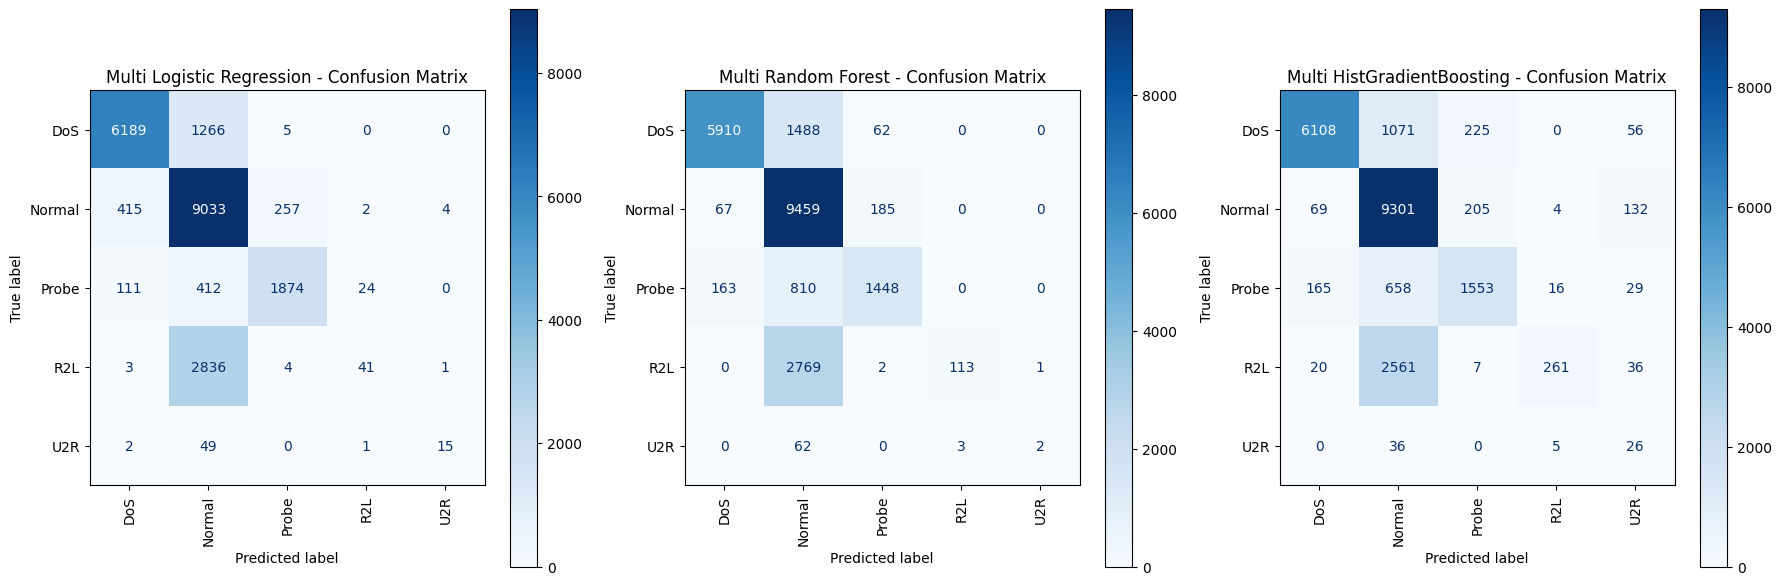

In [ ]:
# MULTICLASS CLASSIFICATION METRICS
print("\n--- Multiclass Classification Metrics ---")
multi_models = [
    (logreg_multi, "Multi Logistic Regression"),
    (rf_multi, "Multi Random Forest"),
    (hgb_multi, "Multi HistGradientBoosting")
]

plt.figure(figsize=(18, 6))
for i, (model, name) in enumerate(multi_models):
    # Confusion Matrix
    plt.subplot(1, len(multi_models), i + 1)
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test_multi, cmap='Blues', ax=plt.gca(), xticks_rotation='vertical')
    plt.title(f'{name} - Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nslkdd/KDDTest+.arff
/kaggle/input/nslkdd/KDDTest-21.arff
/kaggle/input/nslkdd/KDDTest1.jpg
/kaggle/input/nslkdd/KDDTrain+.txt
/kaggle/input/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/nslkdd/KDDTest-21.txt
/kaggle/input/nslkdd/KDDTest+.txt
/kaggle/input/nslkdd/KDDTrain+.arff
/kaggle/input/nslkdd/index.html
/kaggle/input/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/nslkdd/KDDTrain1.jpg
/kaggle/input/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/nslkdd/nsl-kdd/KDDTest-21.txt
/kaggle/input/nslkdd/nsl-kdd/KDDTest+.txt
/kaggle/input/nslkdd/nsl-kdd/KDDTrain+.arff
/kaggle/input/nslkdd/nsl-kdd/index.html
/kaggle/input/nslkdd/nsl-kdd/KDDTrain+_20Percent.arff
/kaggle/input/nslkdd/nsl-kdd/KDDTrain1.jpg


In [ ]:
import pandas as pd
import numpy as np

TRAIN_PATH = "/kaggle/input/nslkdd/KDDTrain+.txt"
TEST_PATH  = "/kaggle/input/nslkdd/KDDTest+.txt"



In [ ]:
kdd_columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv(TRAIN_PATH, names=kdd_columns)
test_df  = pd.read_csv(TEST_PATH,  names=kdd_columns)

print(train_df.shape, test_df.shape)
train_df.head()


(125973, 43) (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
dos_attacks = {
    "back","land","neptune","pod","smurf","teardrop","mailbomb","apache2",
    "processtable","udpstorm","worm"
}
probe_attacks = {"ipsweep","nmap","portsweep","satan","mscan","saint"}
r2l_attacks = {
    "ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient",
    "warezmaster","sendmail","named","snmpgetattack","snmpguess","xlock","xsnoop","httptunnel"
}
u2r_attacks = {"buffer_overflow","loadmodule","perl","rootkit","ps","sqlattack","xterm"}

def to_attack_category(lbl: str) -> str:
    if lbl == "normal":
        return "Normal"
    if lbl in dos_attacks:
        return "DoS"
    if lbl in probe_attacks:
        return "Probe"
    if lbl in r2l_attacks:
        return "R2L"
    if lbl in u2r_attacks:
        return "U2R"
    # unknown label fallback (sometimes appears)
    return "Other"

for df in (train_df, test_df):
    df["attack_cat"] = df["label"].astype(str).apply(to_attack_category)
    df["binary"] = np.where(df["label"].astype(str) == "normal", "Normal", "Attack")

print(train_df["attack_cat"].value_counts())


attack_cat
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


**PREPROCESSING**

In [ ]:

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


TRAIN_PATH = "/kaggle/input/nslkdd/KDDTrain+.txt"
TEST_PATH  = "/kaggle/input/nslkdd/KDDTest+.txt"

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

train_df = pd.read_csv(TRAIN_PATH, names=columns)
test_df  = pd.read_csv(TEST_PATH,  names=columns)


# Binary target
train_df["binary"] = np.where(train_df["label"] == "normal", "Normal", "Attack")
test_df["binary"]  = np.where(test_df["label"] == "normal", "Normal", "Attack")


# Multiclass target
dos = {"back","land","neptune","pod","smurf","teardrop","mailbomb","apache2","processtable","udpstorm","worm"}
probe = {"ipsweep","nmap","portsweep","satan","mscan","saint"}
r2l = {"ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster",
       "sendmail","named","snmpgetattack","snmpguess","xlock","xsnoop","httptunnel"}
u2r = {"buffer_overflow","loadmodule","perl","rootkit","ps","sqlattack","xterm"}

def map_attack(lbl):
    if lbl == "normal": return "Normal"
    if lbl in dos: return "DoS"
    if lbl in probe: return "Probe"
    if lbl in r2l: return "R2L"
    if lbl in u2r: return "U2R"
    return "Other"

train_df["attack_cat"] = train_df["label"].apply(map_attack)
test_df["attack_cat"]  = test_df["label"].apply(map_attack)


# Feature matrix
X_train = train_df.drop(columns=["label","difficulty","binary","attack_cat"])
X_test  = test_df.drop(columns=["label","difficulty","binary","attack_cat"])

y_train_bin = train_df["binary"]
y_test_bin  = test_df["binary"]

y_train_multi = train_df["attack_cat"]
y_test_multi  = test_df["attack_cat"]


# Preprocessing pipeline
cat_cols = ["protocol_type","service","flag"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])


**Model Run**

In [ ]:
# ================================
# ALL MODELS (BINARY + MULTICLASS)
# ================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate(model, X, y, name):
    pred = model.predict(X)
    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("Macro F1:", round(f1_score(y, pred, average="macro"), 4))
    print(classification_report(y, pred))

# -------------------------
# BINARY CLASSIFICATION
# -------------------------

logreg_bin = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=5000))
])

rf_bin = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42))
])

hgb_bin = Pipeline([
    ("prep", preprocess),
    ("clf", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, random_state=42))
])

for model, name in [
    (logreg_bin, "Binary Logistic Regression"),
    (rf_bin, "Binary Random Forest"),
    (hgb_bin, "Binary HistGradientBoosting")
]:
    model.fit(X_train, y_train_bin)
    evaluate(model, X_test, y_test_bin, name)

# -------------------------
# MULTICLASS CLASSIFICATION
# -------------------------

logreg_multi = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=8000))
])

rf_multi = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=600, n_jobs=-1, random_state=42))
])

hgb_multi = Pipeline([
    ("prep", preprocess),
    ("clf", HistGradientBoostingClassifier(max_iter=600, learning_rate=0.06, random_state=42))
])

for model, name in [
    (logreg_multi, "Multi Logistic Regression"),
    (rf_multi, "Multi Random Forest"),
    (hgb_multi, "Multi HistGradientBoosting")
]:
    model.fit(X_train, y_train_multi)
    evaluate(model, X_test, y_test_multi, name)



Binary Logistic Regression
Accuracy: 0.7536
Macro F1: 0.7532
              precision    recall  f1-score   support

      Attack       0.92      0.62      0.74     12833
      Normal       0.65      0.93      0.76      9711

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544


Binary Random Forest
Accuracy: 0.7711
Macro F1: 0.7701
              precision    recall  f1-score   support

      Attack       0.97      0.62      0.75     12833
      Normal       0.66      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544


Binary HistGradientBoosting
Accuracy: 0.7991
Macro F1: 0.7988
              precision    recall  f1-score   support

      Attack       0.97      0.67      0.79     12833
      Normal       0.69      0.97      0.81      9711

 